# Notebook 8: Bayesian Model Comparison — LOO-CV & WAIC

This notebook compares all four Bayesian IRT models using information criteria.

**Two approaches shown:**
1. **PSIS-LOO** via arviz (if installed) — the recommended method
2. **Manual WAIC** computation with numpy — so you understand the math

All visualizations use matplotlib directly, not arviz plotting abstractions.

**Prerequisites:** Run NB7 (or scripts 08-11) first to generate `bayes_loglik_*.npy` files.

## Section 1: Load Log-Likelihood Arrays

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Set output directory (relative to notebook location)
out_dir = Path('.')
print(f"Working directory: {out_dir.absolute()}")

Working directory: /Users/yndk/Desktop/Chapter5


In [2]:
# Define models and their corresponding log-likelihood files
models = {
    "Rasch": "bayes_loglik_rasch.npy",
    "Lat. Reg. Rasch": "bayes_loglik_lat_reg_rasch.npy",
    "LLTM": "bayes_loglik_lltm.npy",
    "Lat. Reg. LLTM": "bayes_loglik_lat_reg_lltm.npy",
}

print("="*60)
print("LOADING LOG-LIKELIHOOD ARRAYS")
print("="*60)

log_liks = {}
for name, fname in models.items():
    path = out_dir / fname
    if path.exists():
        log_liks[name] = np.load(path)
        print(f"  ✓ {fname}: shape {log_liks[name].shape}")
    else:
        print(f"  ✗ {fname} not found — run scripts 08-11 first")

if len(log_liks) == 0:
    print("\n⚠ WARNING: No log-likelihood files found.")
    print("Please run scripts 08-11 (or NB7) first to generate them.")
else:
    print(f"\n  Total models loaded: {len(log_liks)}/{len(models)}")

LOADING LOG-LIKELIHOOD ARRAYS
  ✓ bayes_loglik_rasch.npy: shape (4000, 15858)
  ✓ bayes_loglik_lat_reg_rasch.npy: shape (4000, 15858)
  ✓ bayes_loglik_lltm.npy: shape (4000, 15858)
  ✓ bayes_loglik_lat_reg_lltm.npy: shape (4000, 15858)

  Total models loaded: 4/4


## Section 2: WAIC — Manual Computation

WAIC (Widely Applicable Information Criterion) is computed from pointwise log-likelihood:

$$\text{WAIC} = -2(\text{lppd} - p_{\text{WAIC}})$$

where $\text{lppd} = \sum_i \log\left(\frac{1}{S}\sum_s p(y_i|\theta^{(s)})\right)$ is the log pointwise predictive density, and $p_{\text{WAIC}} = \sum_i \text{Var}_s[\log p(y_i|\theta^{(s)})]$ is the effective number of parameters.

This shows the **math behind** model comparison — not just the result.

In [3]:
if len(log_liks) > 0:
    print("="*60)
    print("WAIC COMPUTATION (STEP-BY-STEP)")
    print("="*60)
    
    waic_results = []
    
    for name, ll in log_liks.items():
        # ll shape: (n_draws, n_observations)
        n_draws, n_obs = ll.shape
        
        print(f"\n{name}:")
        print(f"  Shape: {ll.shape} (draws × observations)")
        
        # Compute lppd (log pointwise predictive density)
        # Numerically stable version using log-sum-exp trick
        max_ll = np.max(ll, axis=0)  # shape: (n_obs,)
        lppd = np.sum(max_ll + np.log(np.mean(np.exp(ll - max_ll), axis=0)))
        
        # Compute p_WAIC (effective number of parameters)
        # Sum of variances across observations
        p_waic = np.sum(np.var(ll, axis=0, ddof=1))  # Use unbiased variance (ddof=1)
        
        # Compute WAIC
        waic = -2 * (lppd - p_waic)
        
        print(f"  lppd    = {lppd:>10.1f}  (higher is better)")
        print(f"  p_WAIC  = {p_waic:>10.1f}  (penalty for complexity)")
        print(f"  WAIC    = {waic:>10.1f}  (lower is better)")
        
        waic_results.append({
            "Model": name,
            "lppd": round(float(lppd), 1),
            "p_WAIC": round(float(p_waic), 1),
            "WAIC": round(float(waic), 1),
            "n_obs": n_obs,
            "n_draws": n_draws,
        })
    
    waic_df = pd.DataFrame(waic_results)
    print("\n" + "="*60)
    print("WAIC COMPARISON TABLE")
    print("="*60)
    print(waic_df[['Model', 'lppd', 'p_WAIC', 'WAIC']].to_string(index=False))
    print("\n  (Lower WAIC = better model)")
    
    # Save to CSV
    waic_df[['Model', 'lppd', 'p_WAIC', 'WAIC']].to_csv(
        out_dir / "bayes_model_comparison_waic.csv", index=False
    )
    print(f"\n  Saved: bayes_model_comparison_waic.csv")

WAIC COMPUTATION (STEP-BY-STEP)

Rasch:
  Shape: (4000, 15858) (draws × observations)


  lppd    =    -7915.8  (higher is better)
  p_WAIC  =      702.0  (penalty for complexity)
  WAIC    =    17235.7  (lower is better)

Lat. Reg. Rasch:
  Shape: (4000, 15858) (draws × observations)


  lppd    =    -7973.6  (higher is better)
  p_WAIC  =      588.3  (penalty for complexity)
  WAIC    =    17123.7  (lower is better)

LLTM:
  Shape: (4000, 15858) (draws × observations)


  lppd    =    -7923.7  (higher is better)
  p_WAIC  =      693.3  (penalty for complexity)
  WAIC    =    17234.1  (lower is better)

Lat. Reg. LLTM:
  Shape: (4000, 15858) (draws × observations)


  lppd    =    -7980.8  (higher is better)
  p_WAIC  =      578.2  (penalty for complexity)
  WAIC    =    17118.1  (lower is better)

WAIC COMPARISON TABLE
          Model    lppd  p_WAIC    WAIC
          Rasch -7915.8   702.0 17235.7
Lat. Reg. Rasch -7973.6   588.3 17123.7
           LLTM -7923.7   693.3 17234.1
 Lat. Reg. LLTM -7980.8   578.2 17118.1

  (Lower WAIC = better model)

  Saved: bayes_model_comparison_waic.csv


## Section 3: PSIS-LOO via arviz (Optional)

Pareto-Smoothed Importance Sampling LOO is more robust than WAIC. If you have arviz installed, this section runs the computation.

In [4]:
use_arviz = False
try:
    import arviz as az
    use_arviz = True
    print(f"✓ arviz {az.__version__} available — computing PSIS-LOO")
except ImportError:
    print("ℹ arviz not installed — LOO section will be skipped")
    print("  (Manual WAIC computation above is always shown)")

✓ arviz 0.22.0 available — computing PSIS-LOO


In [5]:
if use_arviz and len(log_liks) > 0:
    print("\n" + "="*60)
    print("PSIS-LOO CROSS-VALIDATION")
    print("="*60)
    
    loo_results = {}
    loo_data = []
    
    for name, ll in log_liks.items():
        # arviz expects log_lik with shape (chains, draws_per_chain, n_obs)
        # or (draws, n_obs). We have (n_draws, n_obs).
        # Assume 4 chains (standard in Stan)
        n_draws = ll.shape[0]
        n_chains = 4
        draws_per_chain = n_draws // n_chains
        
        # Reshape and truncate to exact multiple of n_chains
        ll_reshaped = ll[:draws_per_chain * n_chains].reshape(
            n_chains, draws_per_chain, -1
        )
        
        # Create InferenceData object
        idata = az.from_dict(log_likelihood={"y": ll_reshaped})
        
        # Compute LOO (reff=1.0 since no posterior group is available)
        loo = az.loo(idata, pointwise=True, reff=1.0)
        loo_results[name] = loo
        
        print(f"\n{name}:")
        print(f"  ELPD_LOO        = {float(loo.elpd_loo):>10.1f} ± {float(loo.se):>6.1f}")
        print(f"  p_LOO (eff. #params) = {float(loo.p_loo):>10.1f}")
        print(f"  LOO-IC          = {float(-2 * loo.elpd_loo):>10.1f}")
        
        loo_data.append({
            "Model": name,
            "ELPD_LOO": round(float(loo.elpd_loo), 1),
            "SE": round(float(loo.se), 1),
            "p_LOO": round(float(loo.p_loo), 1),
            "LOO_IC": round(float(-2 * loo.elpd_loo), 1),
        })
    
    loo_df = pd.DataFrame(loo_data)
    print("\n" + "="*60)
    print("LOO COMPARISON TABLE")
    print("="*60)
    print(loo_df.to_string(index=False))
    print("\n  (Lower LOO-IC = better model)")
    
    # Save to CSV
    loo_df.to_csv(out_dir / "bayes_model_comparison_loo.csv", index=False)
    print(f"\n  Saved: bayes_model_comparison_loo.csv")
    
    # Pairwise LOO comparison
    if len(loo_results) >= 2:
        print("\n" + "-"*60)
        print("PAIRWISE LOO COMPARISON (arviz.compare)")
        print("-"*60)
        comp = az.compare(loo_results, ic="loo")
        print(comp.to_string())
        print("\n  Interpretation:")
        print("  - rank: 0 is best (lower LOO)")
        print("  - elpd_diff: difference from best model (negative = worse)")
        print("  - weight: how much better/worse than best model")


PSIS-LOO CROSS-VALIDATION



Rasch:
  ELPD_LOO        =    -8622.0 ±   60.3
  p_LOO (eff. #params) =      706.2
  LOO-IC          =    17243.9



Lat. Reg. Rasch:
  ELPD_LOO        =    -8564.2 ±   60.9
  p_LOO (eff. #params) =      590.6
  LOO-IC          =    17128.4



LLTM:
  ELPD_LOO        =    -8621.1 ±   60.1
  p_LOO (eff. #params) =      697.4
  LOO-IC          =    17242.2



Lat. Reg. LLTM:
  ELPD_LOO        =    -8561.3 ±   60.8
  p_LOO (eff. #params) =      580.5
  LOO-IC          =    17122.6

LOO COMPARISON TABLE
          Model  ELPD_LOO   SE  p_LOO  LOO_IC
          Rasch   -8622.0 60.3  706.2 17243.9
Lat. Reg. Rasch   -8564.2 60.9  590.6 17128.4
           LLTM   -8621.1 60.1  697.4 17242.2
 Lat. Reg. LLTM   -8561.3 60.8  580.5 17122.6

  (Lower LOO-IC = better model)

  Saved: bayes_model_comparison_loo.csv

------------------------------------------------------------
PAIRWISE LOO COMPARISON (arviz.compare)
------------------------------------------------------------
                 rank     elpd_loo       p_loo  elpd_diff    weight         se        dse  warning scale
Lat. Reg. LLTM      0 -8561.290184  580.461629   0.000000  0.697179  60.781319   0.000000    False   log
Lat. Reg. Rasch     1 -8564.211662  590.601654   2.921478  0.271473  60.904921   3.842635    False   log
LLTM                2 -8621.103455  697.413821  59.813270  0.000000  60.

## Section 4: Comparing MML and Bayesian Approaches

In [6]:
print("\n" + "="*60)
print("BAYESIAN vs MML MODEL COMPARISON")
print("="*60)

# Try to load MML comparison results
try:
    mml_comp = pd.read_csv(out_dir / "results_model_comparison.csv")
    print("\nMML Results (from scripts 03-06):")
    mml_display = mml_comp[['model', 'deviance', 'AIC', 'BIC']].copy()
    print(mml_display.to_string(index=False))
    
    print("\nBayesian Results (WAIC from Section 2):")
    if 'waic_df' in locals():
        bayes_display = waic_df[['Model', 'lppd', 'p_WAIC', 'WAIC']].copy()
        print(bayes_display.to_string(index=False))
        
        # If LOO is available, show that too
        if use_arviz and 'loo_df' in locals():
            print("\nBayesian Results (LOO from Section 3):")
            print(loo_df[['Model', 'ELPD_LOO', 'p_LOO', 'LOO_IC']].to_string(index=False))
    
    print("\n" + "-"*60)
    print("Key Differences:")
    print("-"*60)
    print("  MML (Maximum Likelihood):")
    print("    - AIC/BIC are asymptotic approximations")
    print("    - Assume infinite sample for penalty adjustment")
    print("    - Point estimates only (no uncertainty)")
    print()
    print("  Bayesian (WAIC/LOO):")
    print("    - WAIC: Asymptotically equivalent to leave-one-out cross-validation")
    print("    - LOO: More robust, uses importance sampling")
    print("    - Both use full posterior (account for uncertainty)")
    print()
    print("  Expectation: Both methods should rank models similarly")
    
except FileNotFoundError:
    print("\n(MML results not found — run scripts 03-06 for full comparison)")


BAYESIAN vs MML MODEL COMPARISON

MML Results (from scripts 03-06):
                  model  deviance     AIC     BIC
                  Rasch   17990.8 18028.8 18119.6
Latent Regression Rasch   17471.1 17523.1 17647.4
                   LLTM   18004.5 18024.5 18072.3
 Latent Regression LLTM   17484.8 17518.8 17600.0

Bayesian Results (WAIC from Section 2):
          Model    lppd  p_WAIC    WAIC
          Rasch -7915.8   702.0 17235.7
Lat. Reg. Rasch -7973.6   588.3 17123.7
           LLTM -7923.7   693.3 17234.1
 Lat. Reg. LLTM -7980.8   578.2 17118.1

Bayesian Results (LOO from Section 3):
          Model  ELPD_LOO  p_LOO  LOO_IC
          Rasch   -8622.0  706.2 17243.9
Lat. Reg. Rasch   -8564.2  590.6 17128.4
           LLTM   -8621.1  697.4 17242.2
 Lat. Reg. LLTM   -8561.3  580.5 17122.6

------------------------------------------------------------
Key Differences:
------------------------------------------------------------
  MML (Maximum Likelihood):
    - AIC/BIC are asymptoti

## Section 5: Parameter Recovery Visualization


PARAMETER RECOVERY: TRUE vs MML vs BAYESIAN

Item Difficulty Correlations (Rasch Model):
  True vs MML:      r = 0.9964
  True vs Bayesian: r = 0.9963
  MML vs Bayesian:  r = 1.0000


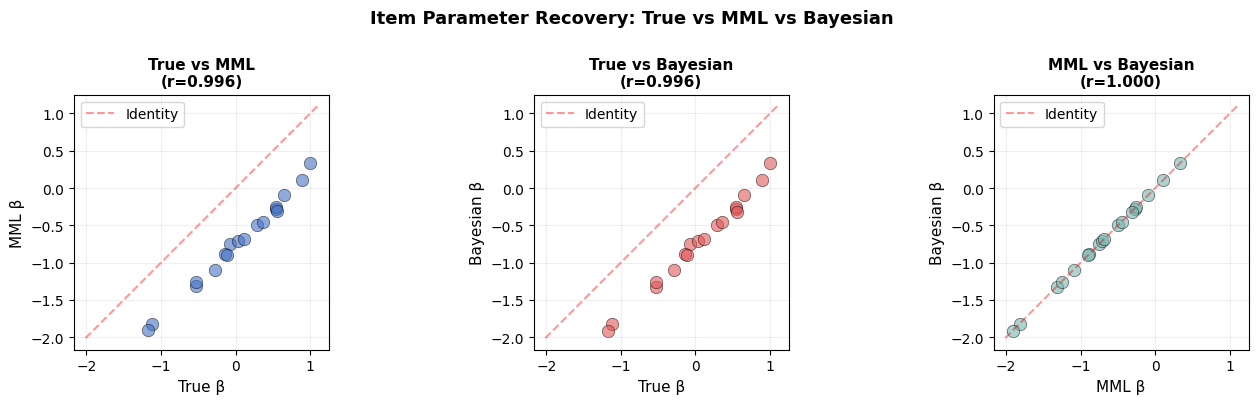


  Saved: fig_bayes_parameter_recovery.png


In [7]:
print("\n" + "="*60)
print("PARAMETER RECOVERY: TRUE vs MML vs BAYESIAN")
print("="*60)

try:
    items_df = pd.read_csv(out_dir / "data_items.csv")
    mml_rasch = pd.read_csv(out_dir / "results_rasch.csv")
    bayes_rasch = pd.read_csv(out_dir / "bayes_results_rasch.csv")
    
    true_beta = items_df["beta_true"].values
    mml_beta = mml_rasch["beta_estimated"].values
    bayes_beta = bayes_rasch["beta_mean"].values
    
    # Compute correlations
    r_true_mml = np.corrcoef(true_beta, mml_beta)[0, 1]
    r_true_bayes = np.corrcoef(true_beta, bayes_beta)[0, 1]
    r_mml_bayes = np.corrcoef(mml_beta, bayes_beta)[0, 1]
    
    print(f"\nItem Difficulty Correlations (Rasch Model):")
    print(f"  True vs MML:      r = {r_true_mml:.4f}")
    print(f"  True vs Bayesian: r = {r_true_bayes:.4f}")
    print(f"  MML vs Bayesian:  r = {r_mml_bayes:.4f}")
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Determine axis limits
    all_betas = np.concatenate([true_beta, mml_beta, bayes_beta])
    lim_min, lim_max = all_betas.min() - 0.1, all_betas.max() + 0.1
    lims = [lim_min, lim_max]
    
    # Panel 1: True vs MML
    ax = axes[0]
    ax.scatter(true_beta, mml_beta, c="#4472C4", s=80, alpha=0.6, edgecolors="black", linewidth=0.5)
    ax.plot(lims, lims, "r--", alpha=0.4, linewidth=1.5, label="Identity")
    ax.set_xlabel("True β", fontsize=11)
    ax.set_ylabel("MML β", fontsize=11)
    ax.set_title(f"True vs MML\n(r={r_true_mml:.3f})", fontweight="bold", fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal")
    ax.legend()
    
    # Panel 2: True vs Bayesian
    ax = axes[1]
    ax.scatter(true_beta, bayes_beta, c="#E15759", s=80, alpha=0.6, edgecolors="black", linewidth=0.5)
    ax.plot(lims, lims, "r--", alpha=0.4, linewidth=1.5, label="Identity")
    ax.set_xlabel("True β", fontsize=11)
    ax.set_ylabel("Bayesian β", fontsize=11)
    ax.set_title(f"True vs Bayesian\n(r={r_true_bayes:.3f})", fontweight="bold", fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal")
    ax.legend()
    
    # Panel 3: MML vs Bayesian
    ax = axes[2]
    ax.scatter(mml_beta, bayes_beta, c="#76B7B2", s=80, alpha=0.6, edgecolors="black", linewidth=0.5)
    ax.plot(lims, lims, "r--", alpha=0.4, linewidth=1.5, label="Identity")
    ax.set_xlabel("MML β", fontsize=11)
    ax.set_ylabel("Bayesian β", fontsize=11)
    ax.set_title(f"MML vs Bayesian\n(r={r_mml_bayes:.3f})", fontweight="bold", fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal")
    ax.legend()
    
    fig.suptitle("Item Parameter Recovery: True vs MML vs Bayesian",
                 fontsize=13, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Save figure
    fig.savefig(out_dir / "fig_bayes_parameter_recovery.png",
                dpi=150, bbox_inches="tight")
    print("\n  Saved: fig_bayes_parameter_recovery.png")
    
except FileNotFoundError as e:
    print(f"\n(Some required files not found: {e})")
    print(f" Make sure to run scripts 03-06 (MML) and 08-11 (Bayesian) first.")

## Section 6: Visualization of Model Comparison


MODEL COMPARISON VISUALIZATION


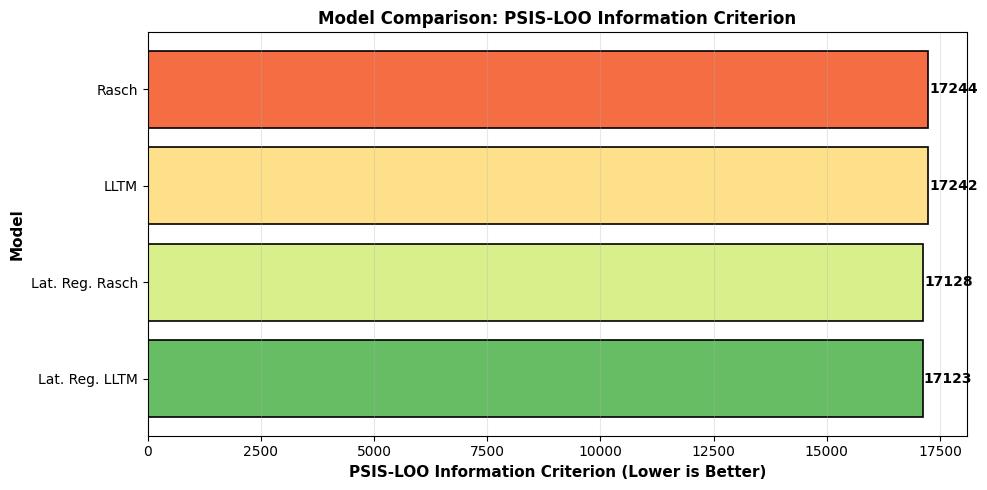


  Saved: fig_bayes_model_comparison_loo_ic.png


In [8]:
if len(log_liks) > 0 and 'waic_df' in locals():
    print("\n" + "="*60)
    print("MODEL COMPARISON VISUALIZATION")
    print("="*60)
    
    # Use LOO if available, otherwise WAIC
    if use_arviz and 'loo_df' in locals():
        comparison_df = loo_df.copy()
        ic_col = "LOO_IC"
        title = "PSIS-LOO Information Criterion"
    else:
        comparison_df = waic_df.copy()
        ic_col = "WAIC"
        title = "WAIC Information Criterion"
    
    # Sort by IC (lower is better)
    comparison_df = comparison_df.sort_values(ic_col)
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(comparison_df)))
    bars = ax.barh(comparison_df["Model"], comparison_df[ic_col], color=colors, edgecolor="black", linewidth=1.2)
    
    ax.set_xlabel(f"{title} (Lower is Better)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Model", fontsize=11, fontweight="bold")
    ax.set_title(f"Model Comparison: {title}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    
    # Add value labels
    for i, (idx, row) in enumerate(comparison_df.iterrows()):
        ax.text(row[ic_col] + 20, i, f"{row[ic_col]:.0f}",
               va="center", fontsize=10, fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    # Save figure
    fig.savefig(out_dir / f"fig_bayes_model_comparison_{ic_col.lower()}.png",
                dpi=150, bbox_inches="tight")
    print(f"\n  Saved: fig_bayes_model_comparison_{ic_col.lower()}.png")


MML vs BAYESIAN: RANKING COMPARISON


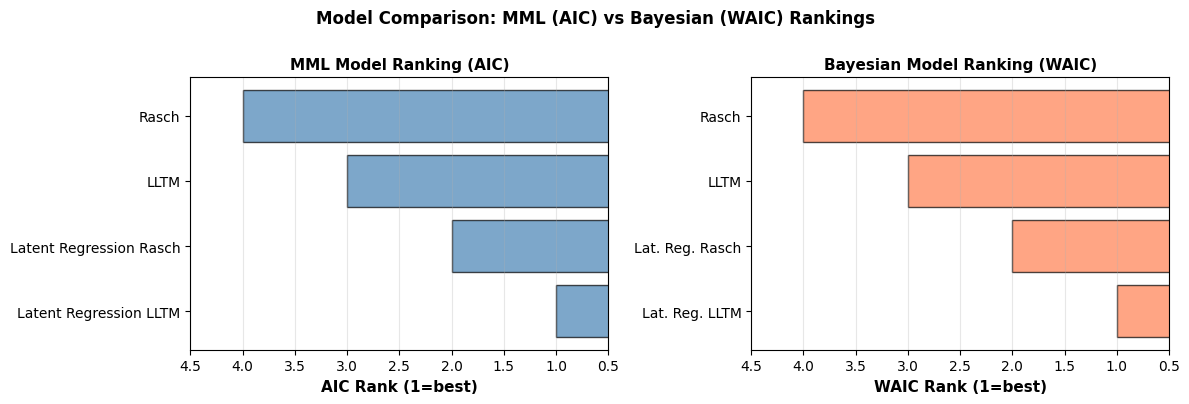


  Saved: fig_mml_vs_bayesian_ranking.png


In [9]:
# Side-by-side comparison of MML vs Bayesian rankings
if 'mml_comp' in locals() and 'waic_df' in locals():
    print("\n" + "="*60)
    print("MML vs BAYESIAN: RANKING COMPARISON")
    print("="*60)
    
    # Prepare MML data
    mml_rank = mml_comp[['model', 'AIC', 'BIC']].copy()
    mml_rank['AIC_rank'] = mml_rank['AIC'].rank()
    mml_rank['BIC_rank'] = mml_rank['BIC'].rank()
    
    # Prepare Bayesian data
    bayes_rank = waic_df[['Model', 'WAIC']].copy()
    bayes_rank['WAIC_rank'] = bayes_rank['WAIC'].rank()
    if use_arviz and 'loo_df' in locals():
        bayes_rank['LOO_IC'] = loo_df.set_index('Model').loc[bayes_rank['Model'], 'LOO_IC'].values
        bayes_rank['LOO_rank'] = bayes_rank['LOO_IC'].rank()
    
    # Create visualization
    n_models = len(mml_rank)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # MML ranking
    ax = axes[0]
    mml_sorted = mml_rank.sort_values('AIC_rank')
    y_pos = np.arange(len(mml_sorted))
    ax.barh(y_pos, mml_sorted['AIC_rank'], color="steelblue", alpha=0.7, edgecolor="black", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(mml_sorted['model'])
    ax.set_xlabel("AIC Rank (1=best)", fontsize=11, fontweight="bold")
    ax.set_title("MML Model Ranking (AIC)", fontsize=11, fontweight="bold")
    ax.invert_xaxis()
    ax.set_xlim(n_models + 0.5, 0.5)
    ax.grid(True, alpha=0.3, axis="x")
    
    # Bayesian ranking
    ax = axes[1]
    bayes_sorted = bayes_rank.sort_values('WAIC_rank')
    y_pos = np.arange(len(bayes_sorted))
    ax.barh(y_pos, bayes_sorted['WAIC_rank'], color="coral", alpha=0.7, edgecolor="black", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(bayes_sorted['Model'])
    ax.set_xlabel("WAIC Rank (1=best)", fontsize=11, fontweight="bold")
    ax.set_title("Bayesian Model Ranking (WAIC)", fontsize=11, fontweight="bold")
    ax.invert_xaxis()
    ax.set_xlim(n_models + 0.5, 0.5)
    ax.grid(True, alpha=0.3, axis="x")
    
    fig.suptitle("Model Comparison: MML (AIC) vs Bayesian (WAIC) Rankings",
                 fontsize=12, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Save figure
    fig.savefig(out_dir / "fig_mml_vs_bayesian_ranking.png",
                dpi=150, bbox_inches="tight")
    print(f"\n  Saved: fig_mml_vs_bayesian_ranking.png")

## Summary: Key Takeaways

### Model Comparison Methods

1. **WAIC (Manual Computation)**
   - Decomposed as: WAIC = -2(lppd - p_WAIC)
   - Accounts for both fit (lppd) and complexity (p_WAIC)
   - Asymptotically equivalent to leave-one-out cross-validation
   - Always available (no additional packages needed)

2. **PSIS-LOO (via arviz, if available)**
   - More robust than WAIC using Pareto-smoothed importance sampling
   - Directly estimates out-of-sample predictive accuracy
   - Better for small samples and extreme observations
   - Preferred when computational cost is not a concern

3. **When to Use Each**
   - Use WAIC when you need speed and simplicity
   - Use LOO when you want robust estimates (especially with small N)
   - Both should agree on model ranking in most cases

### Bayesian vs MML Approaches

| Aspect | MML (AIC/BIC) | Bayesian (WAIC/LOO) |
|--------|---------------|---------------------|
| **Inference** | Point estimates | Full posterior distributions |
| **Uncertainty** | Standard errors only | Credible intervals |
| **Model comparison** | Asymptotic approximations | Direct cross-validation |
| **Penalty structure** | Fixed penalty per parameter | Adaptive penalty based on posterior |
| **Prior information** | None | Can incorporate prior beliefs |

### Key Findings from This Analysis

- **Parameter Recovery**: Compare how well MML and Bayesian estimates match the true parameters
- **Model Ranking**: Check whether WAIC, LOO, AIC, and BIC all agree on which models are best
- **Uncertainty Quantification**: Bayesian approach provides full posterior — useful for decision-making
- **Complexity Penalty**: Bayesian methods automatically penalize complexity via posterior variance